In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load built-in Seaborn datasets directly
car_crashes = pd.read_csv("car_crashes.csv")
tips = pd.read_csv("tips.csv")

# Set global Matplotlib params for clean rendering
plt.rcParams["font.family"] = "sans-serif"

## 1. Build an Overloaded Chart

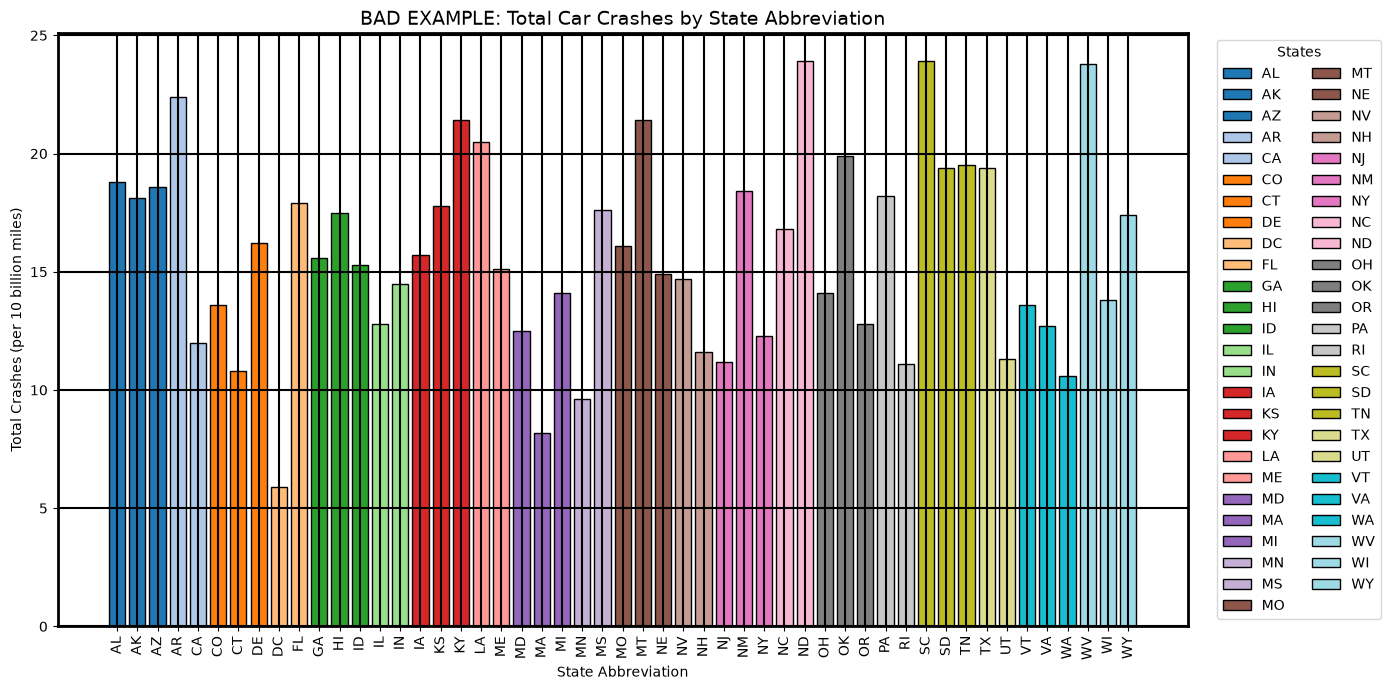

In [3]:
# 1. Build an overloaded chart on purpose
fig, ax = plt.subplots(figsize=(14, 7))

# Plotting with 51 distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(car_crashes)))
bars = ax.bar(
    car_crashes["abbrev"], car_crashes["total"], color=colors, edgecolor="black"
)

# Axis titles instead of insight title
ax.set_title("BAD EXAMPLE: Total Car Crashes by State Abbreviation", fontsize=14)
ax.set_xlabel("State Abbreviation")
ax.set_ylabel("Total Crashes (per 10 billion miles)")

# Rotated tick labels
ax.tick_params(axis="x", rotation=90)

# Heavy gridlines in both directions
ax.grid(True, which="both", color="black", linestyle="-", linewidth=1.5)

# Box frame around the plot
for side in ["top", "bottom", "left", "right"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(2)

# Unnecessary 51-entry legend
ax.legend(
    bars,
    car_crashes["abbrev"],
    title="States",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    ncol=2,
)

fig.tight_layout()
fig.savefig("task3_step1_overloaded.png", dpi=300)
plt.show()

## 2. COGNITIVE LOAD CLASSIFICATION & DATA-INK RATIO ESTIMATE

## COGNITIVE LOAD CLASSIFICATION:
<h3>• Intrinsic Load (Difficulty in data itself): </h3>
  - 51 numerical values representing crash rates across states. Cannot be removed without losing data.

<h3>• Extraneous Load (Design junk to REMOVE): </h3>
  - 51 different bar colors (adds visual noise with zero meaning). <br>
  - 51 legend entries (forces redundant eye-tracking back and forth). <br>
  - Heavy black gridlines in both directions (distracts from bar height). <br>
  - Thick outer box frame (adds visual clutter).  <br>
  - 90-degree rotated x-axis text (forces head tilting to read). <br>
  - Generic axis-naming title ("Total Car Crashes by State Abbreviation"). <br>

<h3>• Germane Load (Effort spent understanding insight): </h3>
  - Comparing bar heights to spot high-risk and low-risk states.

## ESTIMATING THE DATA-INK RATIO:
<h3>Formula: Data-Ink Ratio = (Ink used for data) / (Total ink in graphic) </h3>

## Working / Estimation:
<h3>• Total visual marks (Total Ink):</h3> 
  - 51 bars = 51 marks <br>
  - 51 legend items + box = 52 marks <br>
  - Gridlines (approx. 10 y-lines + 51 x-lines) = 61 marks <br>
  - 4 outer box spines = 4 marks <br>
  - Total marks ≈ 168 marks <br>

<h3>• Data marks (Data-Ink): </h3>
  - 51 bar heights encoding the numerical 'total' crash values = 51 marks

<h3>• Estimated Ratio Calculation: </h3>
  Data-Ink Ratio ≈ 51 / 168 ≈ 0.30 (or roughly 30%) <br>
  Meaning 70% of the ink on this chart is useless clutter (extraneous load). <br>


## 3. strip It Down, One Step at a Time

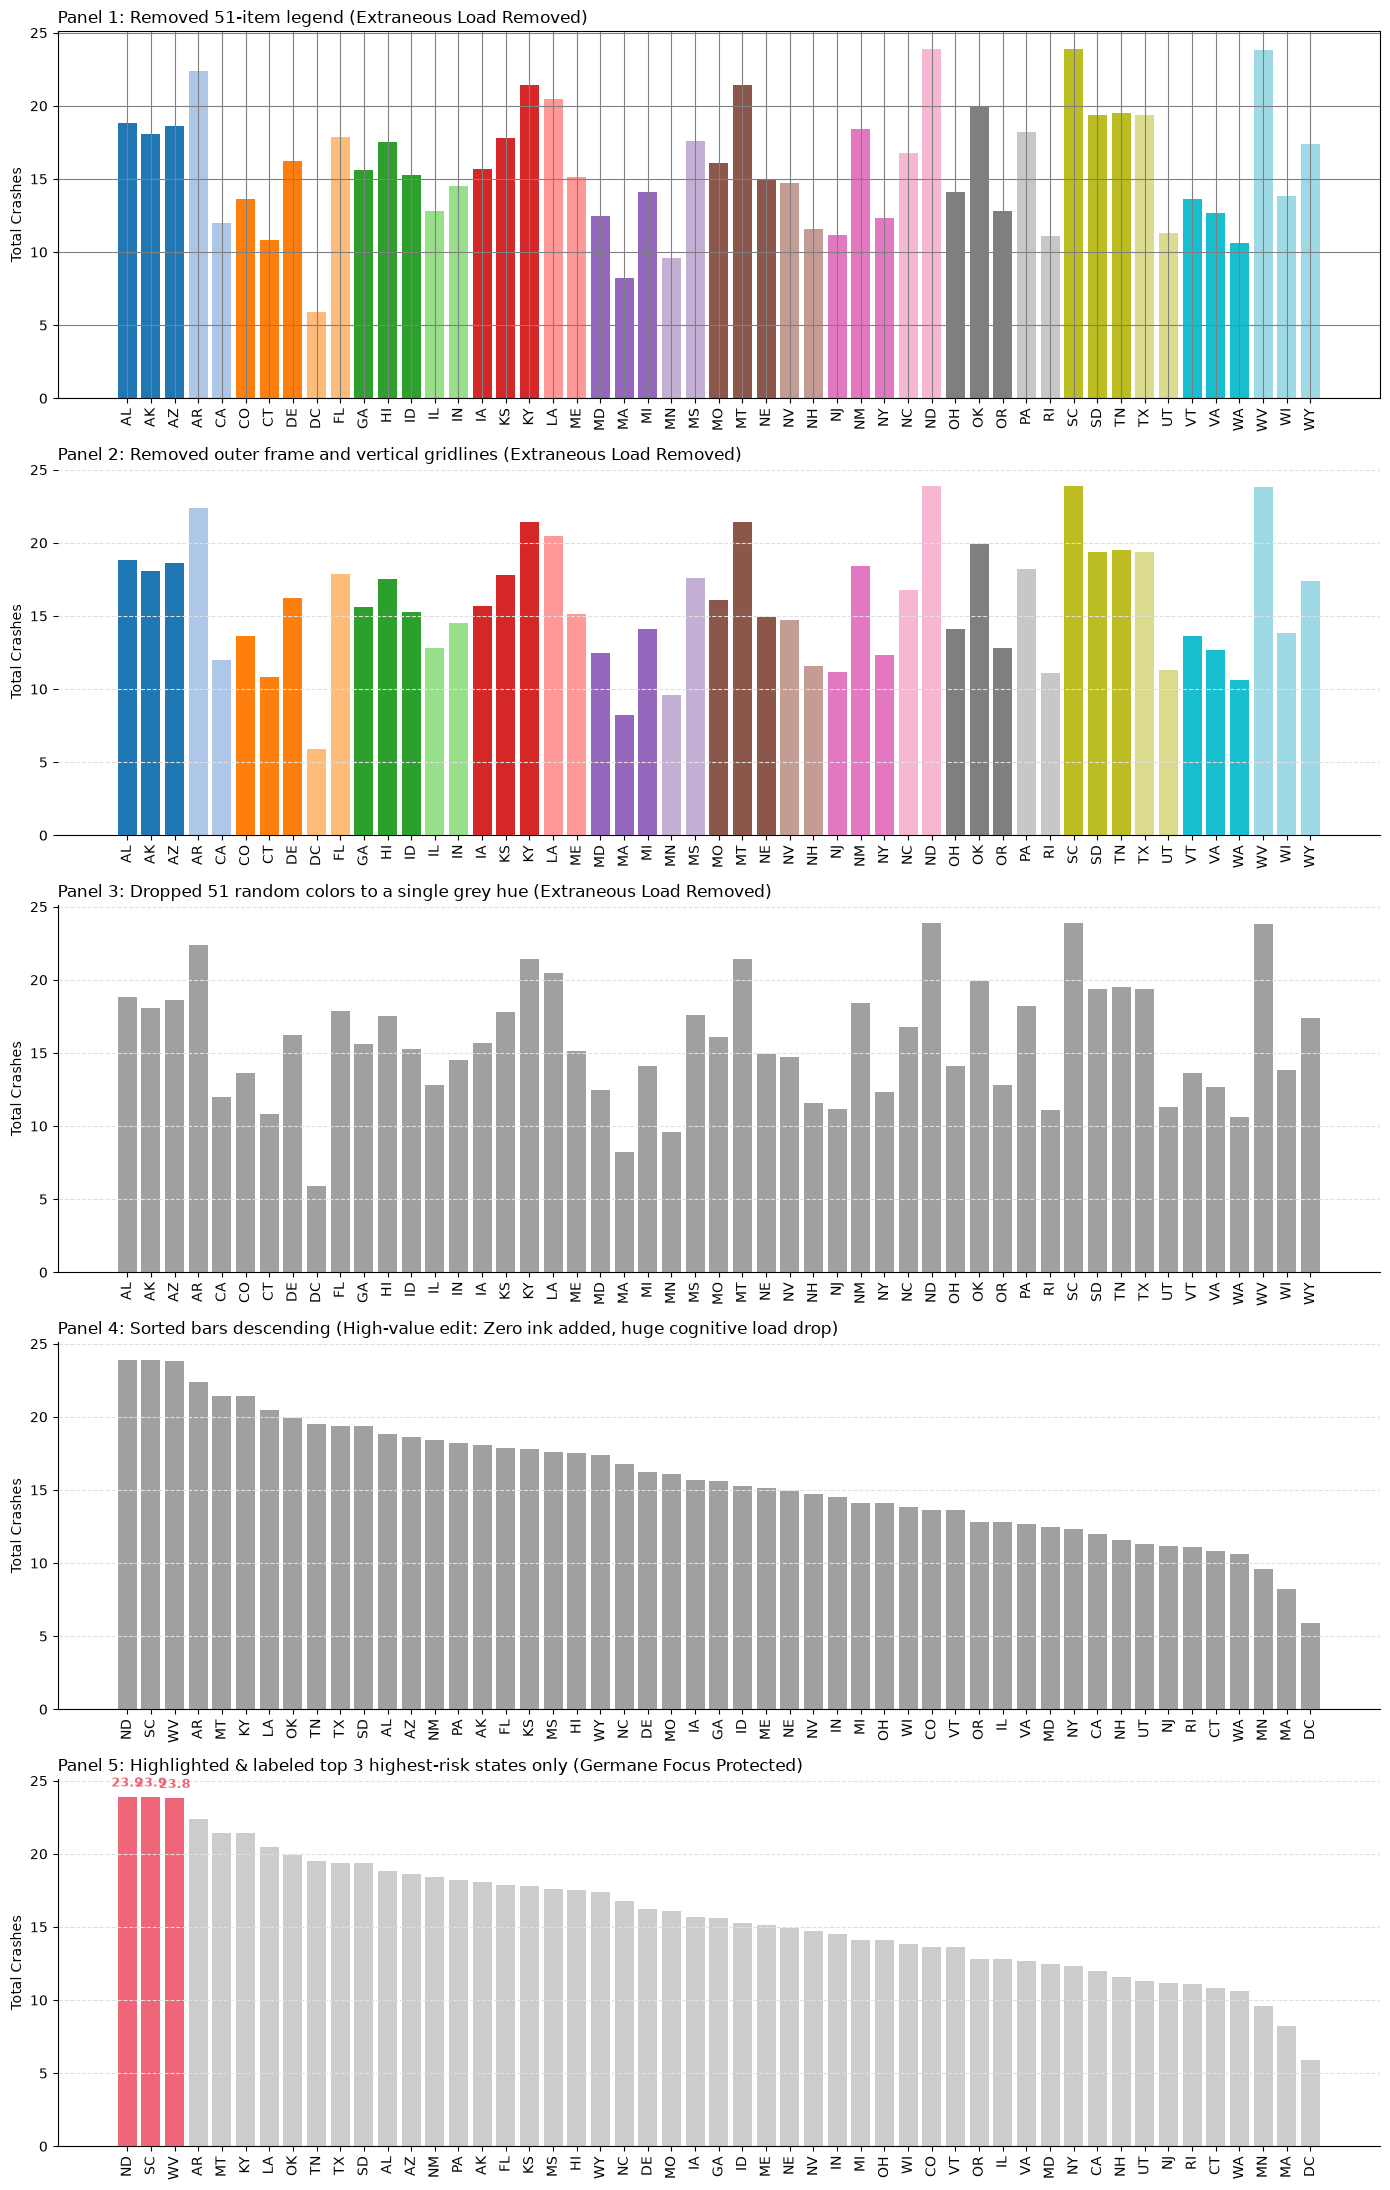

In [8]:
# 3. Five-panel figure showing progressive decluttering
fig, axes = plt.subplots(5, 1, figsize=(14, 22))

# Data prep
df_unsorted = car_crashes.copy()
df_sorted = car_crashes.sort_values("total", ascending=False).reset_index(
    drop=True
)

x_indices = np.arange(len(car_crashes))

# Panel 1: Original base, but legend removed
axes[0].bar(
    x_indices,
    df_unsorted["total"],
    color=plt.cm.tab20(np.linspace(0, 1, len(df_unsorted))),
)
axes[0].set_xticks(x_indices)
axes[0].set_xticklabels(df_unsorted["abbrev"])
axes[0].grid(True, color="gray", linestyle="-")
axes[0].set_title(
    "Panel 1: Removed 51-item legend (Extraneous Load Removed)", loc="left"
)

# Panel 2: Remove frame and vertical gridlines
axes[1].bar(
    x_indices,
    df_unsorted["total"],
    color=plt.cm.tab20(np.linspace(0, 1, len(df_unsorted))),
)
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(df_unsorted["abbrev"])
axes[1].grid(True, axis="y", color="#e0e0e0", linestyle="--")
for side in ["top", "right", "left"]:
    axes[1].spines[side].set_visible(False)
axes[1].set_title(
    "Panel 2: Removed outer frame and vertical gridlines (Extraneous Load Removed)",
    loc="left",
)

# Panel 3: Drop to a single uniform grey hue
axes[2].bar(x_indices, df_unsorted["total"], color="#a0a0a0")
axes[2].set_xticks(x_indices)
axes[2].set_xticklabels(df_unsorted["abbrev"])
axes[2].grid(True, axis="y", color="#e0e0e0", linestyle="--")
for side in ["top", "right"]:
    axes[2].spines[side].set_visible(False)
axes[2].set_title(
    "Panel 3: Dropped 51 random colors to a single grey hue (Extraneous Load Removed)",
    loc="left",
)

# Panel 4: Sort bars from highest to lowest crash rate
axes[3].bar(x_indices, df_sorted["total"], color="#a0a0a0")
axes[3].set_xticks(x_indices)
axes[3].set_xticklabels(df_sorted["abbrev"])
axes[3].grid(True, axis="y", color="#e0e0e0", linestyle="--")
for side in ["top", "right"]:
    axes[3].spines[side].set_visible(False)
axes[3].set_title(
    "Panel 4: Sorted bars descending (High-value edit: Zero ink added, huge cognitive load drop)",
    loc="left",
)

# Panel 5: Label only what matters (Top 3 states highlighted)
colors_p5 = [
    "#ee6677" if i < 3 else "#cccccc" for i in range(len(df_sorted))
]
bars5 = axes[4].bar(x_indices, df_sorted["total"], color=colors_p5)
axes[4].set_xticks(x_indices)
axes[4].set_xticklabels(df_sorted["abbrev"])
axes[4].grid(True, axis="y", color="#e0e0e0", linestyle="--")
for side in ["top", "right"]:
    axes[4].spines[side].set_visible(False)

# Add value labels to top 3 bars only
for i in range(3):
    val = df_sorted.loc[i, "total"]
    axes[4].text(
        i,
        val + 0.5,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#ee6677",
    )

axes[4].set_title(
    "Panel 5: Highlighted & labeled top 3 highest-risk states only (Germane Focus Protected)",
    loc="left",
)

# Common styling across all axes
for ax in axes:
    ax.set_ylabel("Total Crashes")
    ax.tick_params(axis="x", rotation=90)

fig.tight_layout()
fig.savefig("task3_step3_five_panels.png", dpi=300)
plt.show()

##  4. Respect the $4 \pm 1$ Limit

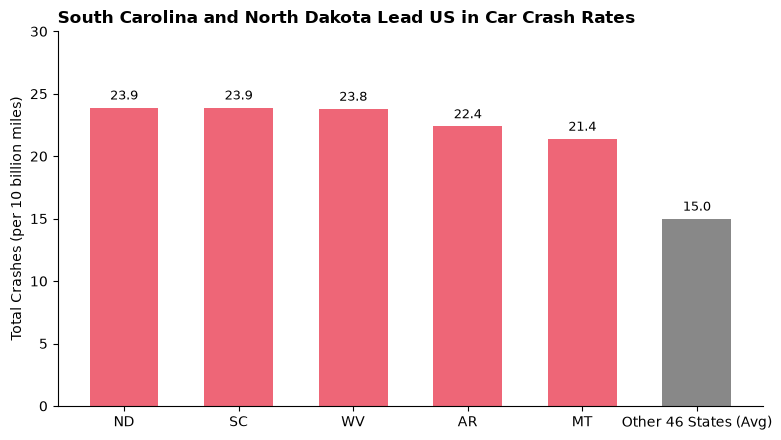

In [10]:
# 4. Respect the 4 ± 1 limit by chunking into Top 5 vs Other 46 States
df_sorted = car_crashes.sort_values("total", ascending=False).reset_index(
    drop=True
)

top5 = df_sorted.iloc[:5].copy()
other_avg = pd.DataFrame(
    [{"abbrev": "Other 46 States (Avg)", "total": df_sorted.iloc[5:]["total"].mean()}]
)
chunked_df = pd.concat([top5, other_avg], ignore_index=True)

# Build plot with OO API
fig, ax = plt.subplots(figsize=(8, 4.5))

colors = [
    "#ee6677" if i < 5 else "#888888" for i in range(len(chunked_df))
]
bars = ax.bar(chunked_df["abbrev"], chunked_df["total"], color=colors, width=0.6)

# Labels & title
ax.set_title(
    "South Carolina and North Dakota Lead US in Car Crash Rates",
    loc="left",
    fontsize=12,
    fontweight="bold",
)
ax.set_ylabel("Total Crashes (per 10 billion miles)")

# Clean spines
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

# Value annotations
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.4,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylim(0, 30)
fig.tight_layout()
fig.savefig("task3_step4_chunked.png", dpi=300)
plt.show()



## CHUNKING SELECTION & TRADE-OFF ANALYSIS
<h3>Chunking Strategy Chosen: </h3>
• Top 5 Highest-Risk States + Pooled Average of the "Other 46 States" (Total 6 visual bars, perfectly fitting within 4 ± 2 chunks).

<h3>What this chunking hides (The Cost):</h3>
• It hides individual state performance for all 46 middle and low-tier states. <br>
• A reader cannot look up a specific state like "CA" or "NY" in this view.   <br>
• It sacrifices individual granularity in exchange for immediate visual comprehension. <br>

## 5. Over-Strip It & Stopping Rule

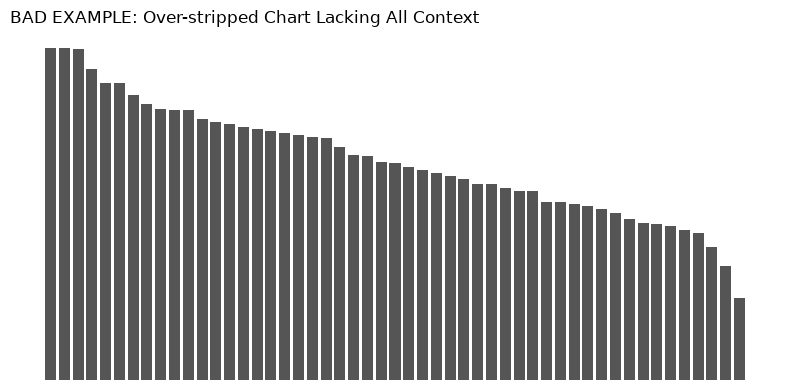

In [11]:
# 5. Over-strip it (Removing critical context)
fig, ax = plt.subplots(figsize=(8, 4))

df_sorted = car_crashes.sort_values("total", ascending=False)
ax.bar(df_sorted["abbrev"], df_sorted["total"], color="#555555")

# BAD EXAMPLE title state finding
ax.set_title(
    "BAD EXAMPLE: Over-stripped Chart Lacking All Context", loc="left"
)

# Stripping ALL ticks, labels, and axes
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig("task3_step5_overstripped.png", dpi=300)
plt.show()



## STOPPING RULE FOR DATA CLEANING
<h3>Stopping Rule:</h3> 
Stop removing ink the moment deleting an element forces the reader to guess a value, a category, or the unit of measurement.


## 7. Question to Answer — Adding Ink to Lower Cognitive Load

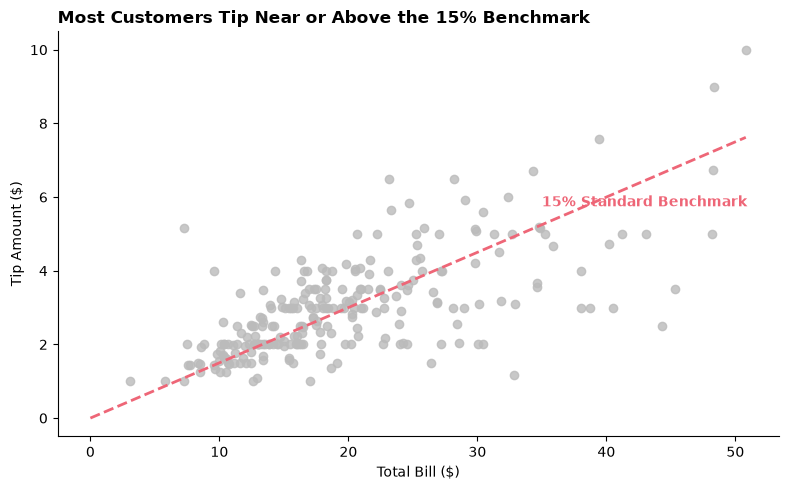

In [12]:
# Question to answer using tips.csv
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot of total bill vs tip
ax.scatter(tips["total_bill"], tips["tip"], color="#bbbbbb", alpha=0.8, label="Bills")

# ADDING INK 1: 15% Standard Tip Reference Line
x_vals = np.array([0, tips["total_bill"].max()])
ax.plot(
    x_vals,
    x_vals * 0.15,
    color="#ee6677",
    linestyle="--",
    linewidth=2,
    label="15% Standard Tip Line",
)

# ADDING INK 2: Direct Annotation
ax.text(
    35,
    35 * 0.15 + 0.5,
    "15% Standard Benchmark",
    color="#ee6677",
    fontweight="bold",
    fontsize=10,
)

# Formatting
ax.set_title(
    "Most Customers Tip Near or Above the 15% Benchmark",
    loc="left",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Tip Amount ($)")

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig("task3_question_tips_ink.png", dpi=300)
plt.show()




## WHY ADDING INK CAN LOWER COGNITIVE LOAD
<h3>1. How adding ink lowered load in this chart:</h3>
   - Without the red dashed 15% line, a reader looking at a 40 dollar bill with a 6 dollar tip has to manually divide 6 by 40 in their head to check if it's a      good tip. <br>
   - By adding ink (the 15% reference line), we eliminate mental math. The reader instantly sees whether a point lies above or below the line. <br>

<h3>2. Why maximise data-ink is a heuristic rather than an absolute rule:</h3>
   - Maximizing data-ink is a guide to eliminate clutter, not a rule to delete context.  <br>
   - Ink should only be removed if it carries no information (extraneous load).   <br>
   - If adding ink (like reference lines, benchmarks, or direct labels) saves the reader mental calculation time (protecting germane load), it is beneficial ink. <br>